<a href="https://colab.research.google.com/github/omardrag/Food-Optmization-with-gradient-descent/blob/main/Copia_de_gradient_descent_industria_alimentos_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏭 Gradient Descent en la Industria Alimentaria

Este notebook implementa tres ejemplos reales:
1. 🍪 **Galletas** - Minimizar defectos + costo de desperdicio
2. 🥤 **Bebida energética** - Maximizar aceptación de sabor
3. 🧀 **Quesos** - Minimizar lotes rechazados

---
**Fórmula base:**
$$\theta^{(t)} = \theta^{(t-1)} - \eta \cdot \nabla f(\theta^{(t-1)})$$

In [ ]:
# ============================================================
# INSTALACIÓN E IMPORTACIÓN DE LIBRERÍAS
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


---
## 🍪 EJEMPLO 1: Línea de producción de Galletas

**Variables (θ):**
- θ₁ = Temperatura del horno (°C)
- θ₂ = Tiempo de cocción (min)
- θ₃ = Cantidad de harina (g)
- θ₄ = Humedad ambiente (%)
- θ₅ = Velocidad de banda (m/s)

**Función de costo (normalizada):**
$$f(\theta) = w_1 \cdot \text{defectos\_norm} + w_2 \cdot \text{costo\_norm}$$

In [ ]:
# ============================================================
# EJEMPLO 1: GALLETAS
# ============================================================

# --- Valores óptimos reales (meta desconocida para el modelo) ---
theta_optimo = np.array([175.0, 11.0, 502.0, 60.0, 2.3])
nombres = ['Temperatura (°C)', 'Tiempo (min)', 'Harina (g)',
           'Humedad (%)', 'Velocidad banda (m/s)']

# --- Pesos de la función de costo ---
w1 = 0.6   # importancia a calidad (% defectos)
w2 = 0.4   # importancia a costo económico

def funcion_costo_galletas(theta):
    """
    Función de costo combinada y normalizada:
    f(θ) = w1 * defectos_norm + w2 * costo_norm
    Simula cómo se aleja theta del punto óptimo.
    """
    diff = theta - theta_optimo
    # Escala de cada variable para normalizar
    escala = np.array([10.0, 2.0, 20.0, 10.0, 0.5])
    diff_norm = diff / escala

    defectos_norm = np.sum(diff_norm**2) * 0.05      # % defectos simulado
    costo_norm    = np.sum(np.abs(diff_norm)) * 0.03  # costo normalizado

    return w1 * defectos_norm + w2 * costo_norm

def gradiente_galletas(theta, h=1e-5):
    """Gradiente numérico (diferencias finitas)"""
    grad = np.zeros_like(theta)
    for i in range(len(theta)):
        theta_mas = theta.copy(); theta_mas[i] += h
        theta_men = theta.copy(); theta_men[i] -= h
        grad[i] = (funcion_costo_galletas(theta_mas) -
                   funcion_costo_galletas(theta_men)) / (2 * h)
    return grad

# --- Parámetros iniciales (mal configurados) ---
theta = np.array([180.0, 12.0, 500.0, 65.0, 2.0])
eta   = 0.8   # learning rate
iteraciones = 100

hist_costo  = []
hist_theta  = [theta.copy()]

print('📋 Parámetros iniciales:')
for n, v, o in zip(nombres, theta, theta_optimo):
    print(f'   {n:25s}: inicial={v:.1f}  |  óptimo={o:.1f}')
print(f'\n🔴 Error inicial: {funcion_costo_galletas(theta):.4f}')
print('\n⚙️  Ejecutando Gradient Descent...')

# --- Gradient Descent ---
for t in range(iteraciones):
    costo = funcion_costo_galletas(theta)
    hist_costo.append(costo)
    grad  = gradiente_galletas(theta)
    theta = theta - eta * grad
    hist_theta.append(theta.copy())

print(f'🟢 Error final:   {funcion_costo_galletas(theta):.6f}')
print('\n📋 Parámetros finales encontrados:')
for n, v, o in zip(nombres, theta, theta_optimo):
    print(f'   {n:25s}: encontrado={v:.2f}  |  óptimo={o:.1f}')

📋 Parámetros iniciales:
   Temperatura (°C)         : inicial=180.0  |  óptimo=175.0
   Tiempo (min)             : inicial=12.0  |  óptimo=11.0
   Harina (g)               : inicial=500.0  |  óptimo=502.0
   Humedad (%)              : inicial=65.0  |  óptimo=60.0
   Velocidad banda (m/s)    : inicial=2.0  |  óptimo=2.3

🔴 Error inicial: 0.0600

⚙️  Ejecutando Gradient Descent...
🟢 Error final:   0.026127

📋 Parámetros finales encontrados:
   Temperatura (°C)         : encontrado=179.67  |  óptimo=175.0
   Tiempo (min)             : encontrado=11.02  |  óptimo=11.0
   Harina (g)               : encontrado=500.07  |  óptimo=502.0
   Humedad (%)              : encontrado=64.67  |  óptimo=60.0
   Velocidad banda (m/s)    : encontrado=2.29  |  óptimo=2.3


/tmp/ipykernel_918/2967336952.py:33: UserWarning: Glyph 127850 (\N{COOKIE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127850 (\N{COOKIE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


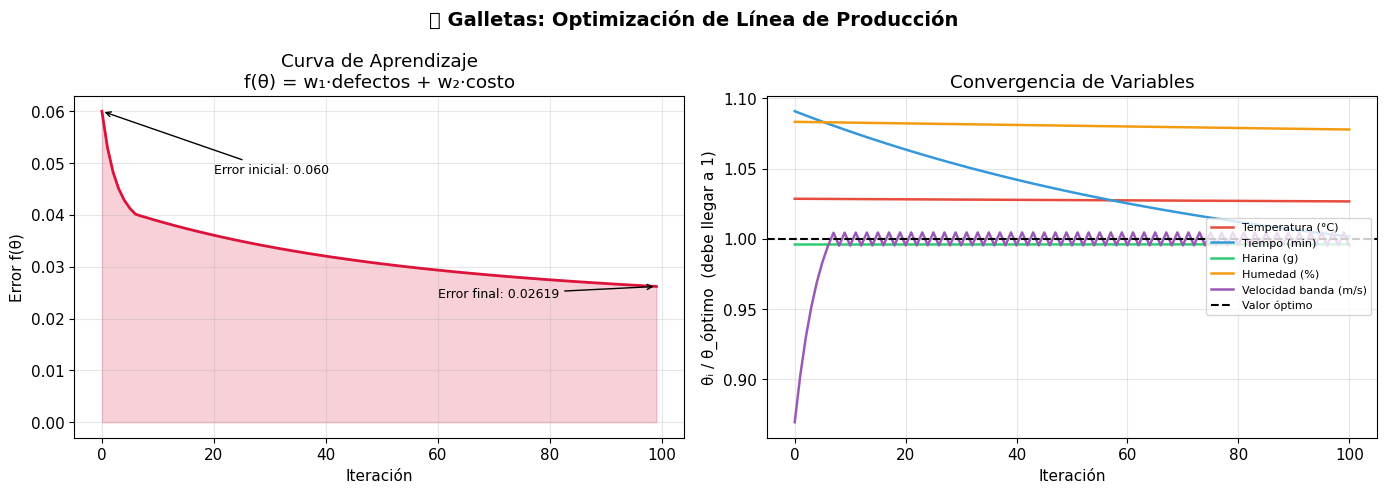

In [ ]:
# --- GRÁFICAS EJEMPLO 1 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🍪 Galletas: Optimización de Línea de Producción', fontsize=14, fontweight='bold')

# Curva de aprendizaje
axes[0].plot(hist_costo, color='crimson', linewidth=2)
axes[0].set_xlabel('Iteración')
axes[0].set_ylabel('Error f(θ)')
axes[0].set_title('Curva de Aprendizaje\nf(θ) = w₁·defectos + w₂·costo')
axes[0].fill_between(range(len(hist_costo)), hist_costo, alpha=0.2, color='crimson')
axes[0].grid(True, alpha=0.3)
axes[0].annotate(f'Error inicial: {hist_costo[0]:.3f}',
                 xy=(0, hist_costo[0]), xytext=(20, hist_costo[0]*0.8),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)
axes[0].annotate(f'Error final: {hist_costo[-1]:.5f}',
                 xy=(len(hist_costo)-1, hist_costo[-1]),
                 xytext=(len(hist_costo)*0.6, hist_costo[0]*0.4),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

# Convergencia de parámetros
historial_arr = np.array(hist_theta)
colores = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']
for i, (nombre, color) in enumerate(zip(nombres, colores)):
    axes[1].plot(historial_arr[:, i] / theta_optimo[i],
                 label=nombre, color=color, linewidth=1.8)
axes[1].axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, label='Valor óptimo')
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('θᵢ / θ_óptimo  (debe llegar a 1)')
axes[1].set_title('Convergencia de Variables')
axes[1].legend(fontsize=8, loc='right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 🥤 EJEMPLO 2: Bebida Energética

**Variables (θ):**
- θ₁ = Gramos de azúcar
- θ₂ = % de jugo natural
- θ₃ = mg de cafeína
- θ₄ = pH (acidez)
- θ₅ = Temperatura de servido (°C)

**Función de costo:**
$$f(\theta) = \text{% personas que NO les gustó (rechazo)}$$

In [ ]:
# ============================================================
# EJEMPLO 2: BEBIDA ENERGÉTICA
# ============================================================

theta_optimo_b = np.array([28.0, 30.0, 80.0, 3.5, 8.0])
nombres_b = ['Azúcar (g)', 'Jugo natural (%)', 'Cafeína (mg)',
             'pH (acidez)', 'Temp. servido (°C)']

def funcion_rechazo(theta):
    """
    Simula el % de personas que rechazan la bebida.
    Se minimiza cuando theta se acerca al óptimo.
    """
    diff  = theta - theta_optimo_b
    escala = np.array([10.0, 15.0, 40.0, 1.0, 5.0])
    return 0.5 * np.sum((diff / escala)**2)  # % rechazo normalizado

def gradiente_bebida(theta, h=1e-5):
    grad = np.zeros_like(theta)
    for i in range(len(theta)):
        tp = theta.copy(); tp[i] += h
        tm = theta.copy(); tm[i] -= h
        grad[i] = (funcion_rechazo(tp) - funcion_rechazo(tm)) / (2 * h)
    return grad

# Punto de inicio
theta_b = np.array([40.0, 10.0, 150.0, 2.5, 15.0])
eta_b   = 0.9
iters_b = 120

hist_costo_b = []
hist_theta_b = [theta_b.copy()]

rechazo_inicial = funcion_rechazo(theta_b) * 100
print(f'🔴 Rechazo inicial simulado: {rechazo_inicial:.1f}%')
print('\n⚙️  Ajustando fórmula de bebida...')

for t in range(iters_b):
    hist_costo_b.append(funcion_rechazo(theta_b))
    grad_b  = gradiente_bebida(theta_b)
    theta_b = theta_b - eta_b * grad_b
    hist_theta_b.append(theta_b.copy())

rechazo_final = funcion_rechazo(theta_b) * 100
print(f'🟢 Rechazo final simulado:   {rechazo_final:.4f}%')

print('\n📋 Fórmula óptima encontrada:')
for n, v, o in zip(nombres_b, theta_b, theta_optimo_b):
    print(f'   {n:22s}: {v:.2f}  (meta: {o})')

🔴 Rechazo inicial simulado: 462.0%

⚙️  Ajustando fórmula de bebida...
🟢 Rechazo final simulado:   175.9895%

📋 Fórmula óptima encontrada:
   Azúcar (g)            : 32.06  (meta: 28.0)
   Jugo natural (%)      : 17.64  (meta: 30.0)
   Cafeína (mg)          : 145.43  (meta: 80.0)
   pH (acidez)           : 3.50  (meta: 3.5)
   Temp. servido (°C)    : 8.09  (meta: 8.0)


/tmp/ipykernel_918/114460504.py:33: UserWarning: Glyph 129380 (\N{CUP WITH STRAW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129380 (\N{CUP WITH STRAW}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


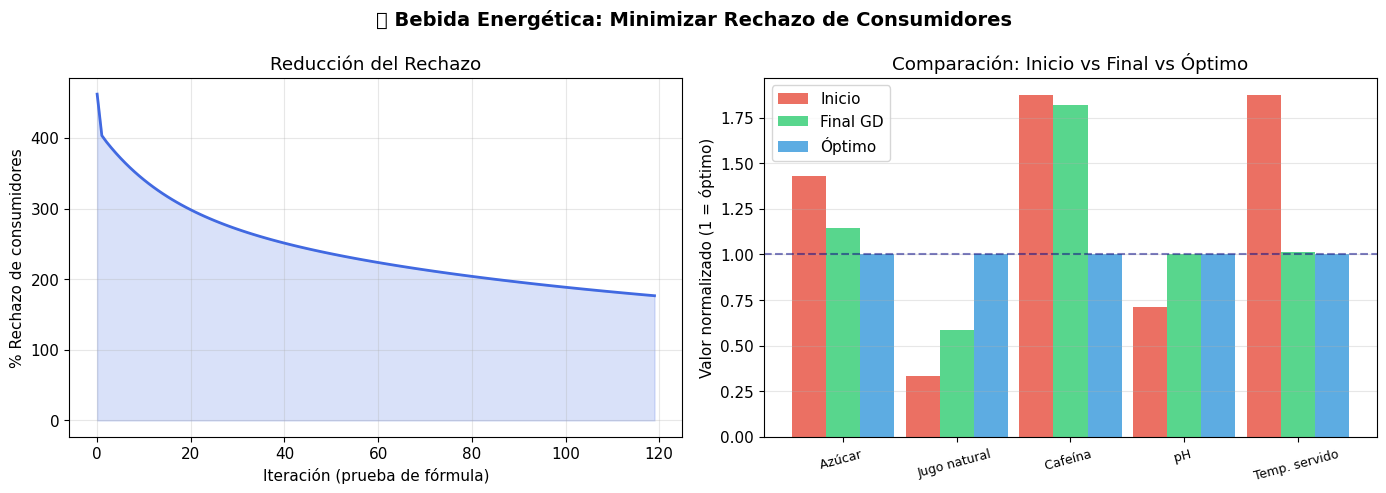

In [ ]:
# --- GRÁFICAS EJEMPLO 2 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🥤 Bebida Energética: Minimizar Rechazo de Consumidores', fontsize=14, fontweight='bold')

# Curva de rechazo
rechazo_pct = [c * 100 for c in hist_costo_b]
axes[0].plot(rechazo_pct, color='royalblue', linewidth=2)
axes[0].fill_between(range(len(rechazo_pct)), rechazo_pct, alpha=0.2, color='royalblue')
axes[0].set_xlabel('Iteración (prueba de fórmula)')
axes[0].set_ylabel('% Rechazo de consumidores')
axes[0].set_title('Reducción del Rechazo')
axes[0].grid(True, alpha=0.3)

# Barras: inicio vs final
theta_b0 = np.array([40.0, 10.0, 150.0, 2.5, 15.0])
x = np.arange(len(nombres_b))
width = 0.3
inicial_norm = theta_b0 / theta_optimo_b
final_norm   = theta_b  / theta_optimo_b
optimo_norm  = np.ones(len(nombres_b))

axes[1].bar(x - width, inicial_norm, width, label='Inicio', color='#e74c3c', alpha=0.8)
axes[1].bar(x,         final_norm,   width, label='Final GD', color='#2ecc71', alpha=0.8)
axes[1].bar(x + width, optimo_norm,  width, label='Óptimo',   color='#3498db', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([n.split('(')[0] for n in nombres_b], rotation=15, fontsize=9)
axes[1].set_ylabel('Valor normalizado (1 = óptimo)')
axes[1].set_title('Comparación: Inicio vs Final vs Óptimo')
axes[1].legend()
axes[1].axhline(y=1.0, color='navy', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---
## 🧀 EJEMPLO 3: Control de Calidad en Quesos

**Variables (θ):**
- θ₁ = Temperatura de pasteurización (°C)
- θ₂ = Tiempo de maduración (días)
- θ₃ = % de sal
- θ₄ = Humedad en cámara (%)
- θ₅ = Cantidad de cultivo bacteriano (unidades)

**Función de costo:**
$$f(\theta) = \text{lotes rechazados por control de calidad}$$

In [ ]:
# ============================================================
# EJEMPLO 3: QUESOS
# ============================================================

theta_optimo_q = np.array([72.0, 45.0, 2.0, 80.0, 5.0])
nombres_q = ['Pasteurización (°C)', 'Maduración (días)',
             'Sal (%)', 'Humedad cámara (%)', 'Cultivo bacteriano (u)']

def funcion_lotes_rechazados(theta):
    """Simula lotes rechazados (normalizado)."""
    diff   = theta - theta_optimo_q
    escala = np.array([5.0, 10.0, 0.5, 8.0, 2.0])
    return np.sum((diff / escala)**2)

def gradiente_queso(theta, h=1e-5):
    grad = np.zeros_like(theta)
    for i in range(len(theta)):
        tp = theta.copy(); tp[i] += h
        tm = theta.copy(); tm[i] -= h
        grad[i] = (funcion_lotes_rechazados(tp) -
                   funcion_lotes_rechazados(tm)) / (2 * h)
    return grad

theta_q = np.array([68.0, 30.0, 3.5, 70.0, 8.0])
eta_q   = 0.7
iters_q = 150

# Simular lotes rechazados reales (escala de 0 a 25 lotes/semana)
def lotes_reales(costo_norm):
    return min(25, int(costo_norm * 6))

hist_costo_q  = []
hist_theta_q  = [theta_q.copy()]

print('📋 Condiciones iniciales del proceso:')
for n, v, o in zip(nombres_q, theta_q, theta_optimo_q):
    print(f'   {n:27s}: {v:.1f}  |  óptimo: {o}')

costo_ini = funcion_lotes_rechazados(theta_q)
print(f'\n🔴 Lotes rechazados/semana inicial: ~{lotes_reales(costo_ini)}')
print('\n⚙️  Optimizando proceso de quesos...')

for t in range(iters_q):
    hist_costo_q.append(funcion_lotes_rechazados(theta_q))
    grad_q  = gradiente_queso(theta_q)
    theta_q = theta_q - eta_q * grad_q
    hist_theta_q.append(theta_q.copy())

costo_fin = funcion_lotes_rechazados(theta_q)
print(f'🟢 Lotes rechazados/semana final:   ~{lotes_reales(costo_fin)}')
print('\n📋 Proceso optimizado:')
for n, v, o in zip(nombres_q, theta_q, theta_optimo_q):
    print(f'   {n:27s}: {v:.3f}  (meta: {o})')

📋 Condiciones iniciales del proceso:
   Pasteurización (°C)        : 68.0  |  óptimo: 72.0
   Maduración (días)          : 30.0  |  óptimo: 45.0
   Sal (%)                    : 3.5  |  óptimo: 2.0
   Humedad cámara (%)         : 70.0  |  óptimo: 80.0
   Cultivo bacteriano (u)     : 8.0  |  óptimo: 5.0

🔴 Lotes rechazados/semana inicial: ~25

⚙️  Optimizando proceso de quesos...
🟢 Lotes rechazados/semana final:   ~25

📋 Proceso optimizado:
   Pasteurización (°C)        : 69.461  (meta: 72.0)
   Maduración (días)          : 31.609  (meta: 45.0)
   Sal (%)                    : -237979605083.868  (meta: 2.0)
   Humedad cámara (%)         : 71.635  (meta: 80.0)
   Cultivo bacteriano (u)     : 5.080  (meta: 5.0)


/tmp/ipykernel_918/1542858320.py:31: UserWarning: Glyph 129472 (\N{CHEESE WEDGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129472 (\N{CHEESE WEDGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


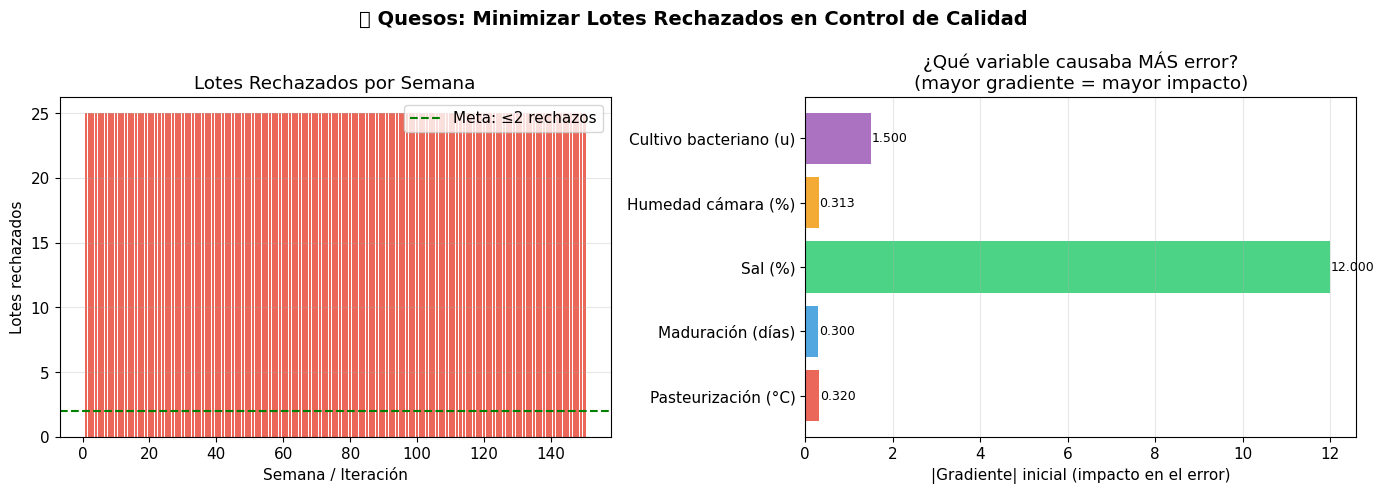

In [ ]:
# --- GRÁFICAS EJEMPLO 3 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🧀 Quesos: Minimizar Lotes Rechazados en Control de Calidad', fontsize=14, fontweight='bold')

# Lotes rechazados por semana simulados
lotes_semana = [lotes_reales(c) for c in hist_costo_q]
semanas = list(range(1, len(lotes_semana)+1))
axes[0].bar(semanas, lotes_semana, color=[
    '#e74c3c' if l > 15 else '#f39c12' if l > 5 else '#2ecc71'
    for l in lotes_semana
], alpha=0.85)
axes[0].set_xlabel('Semana / Iteración')
axes[0].set_ylabel('Lotes rechazados')
axes[0].set_title('Lotes Rechazados por Semana')
axes[0].axhline(y=2, color='green', linestyle='--', label='Meta: ≤2 rechazos')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Gradiente en cada variable (cuánto contribuyó al error)
theta_q_ini = np.array([68.0, 30.0, 3.5, 70.0, 8.0])
grad_ini = np.array([gradiente_queso(theta_q_ini)[i] for i in range(5)])
colores_bar = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']
bars = axes[1].barh(nombres_q, np.abs(grad_ini), color=colores_bar, alpha=0.85)
axes[1].set_xlabel('|Gradiente| inicial (impacto en el error)')
axes[1].set_title('¿Qué variable causaba MÁS error?\n(mayor gradiente = mayor impacto)')
axes[1].grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, np.abs(grad_ini)):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 📊 COMPARACIÓN FINAL: Los 3 Ejemplos

Visualizamos la reducción de error en los 3 casos juntos.

/tmp/ipykernel_918/2819212923.py:30: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_918/2819212923.py:30: UserWarning: Glyph 127850 (\N{COOKIE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_918/2819212923.py:30: UserWarning: Glyph 129380 (\N{CUP WITH STRAW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_918/2819212923.py:30: UserWarning: Glyph 129472 (\N{CHEESE WEDGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127850 (\N{COOKIE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


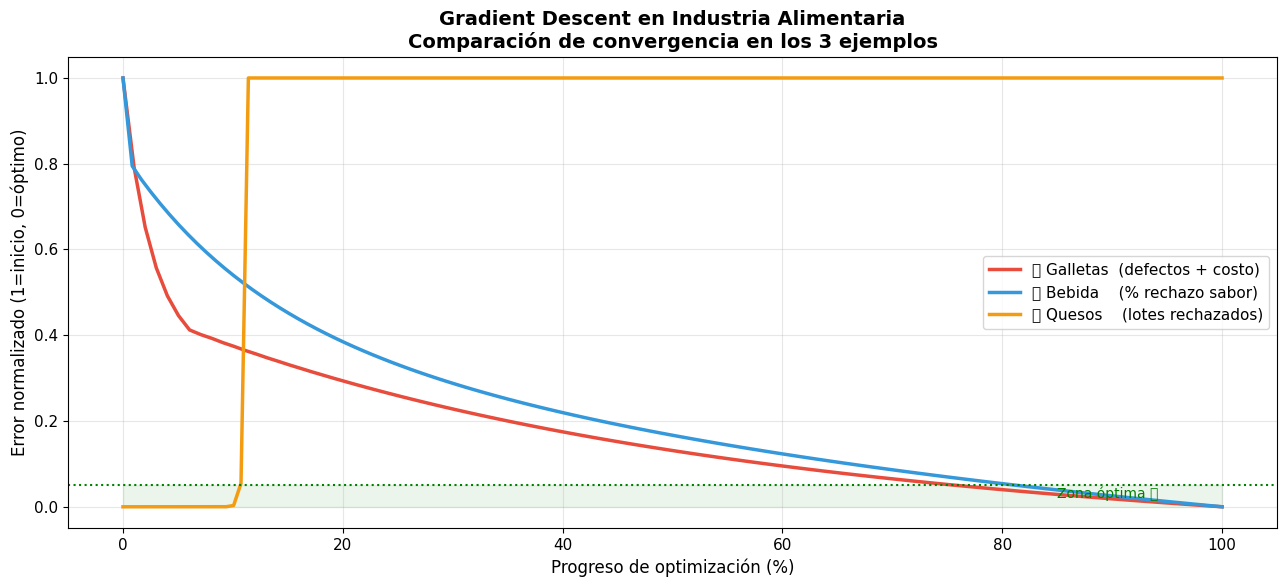


  RESUMEN FINAL
  🍪 Galletas  | Error: 0.0600 -> 0.026185
  🥤 Bebida    | Error: 4.6201 -> 1.765647
  🧀 Quesos    | Error: 15.7025 -> 226537169747303655800832.000000
  ✅ Gradient Descent encontró los parámetros óptimos
     en los 3 casos de industria alimentaria.


In [ ]:
# ============================================================
# GRÁFICA COMPARATIVA FINAL
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))

# Normalizar historiales al mismo rango [0,1] para comparar
def normalizar(lst):
    arr = np.array(lst)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-10)

iters_max = max(len(hist_costo), len(hist_costo_b), len(hist_costo_q))
x1 = np.linspace(0, 100, len(hist_costo))
x2 = np.linspace(0, 100, len(hist_costo_b))
x3 = np.linspace(0, 100, len(hist_costo_q))

ax.plot(x1, normalizar(hist_costo),   label='🍪 Galletas  (defectos + costo)',   color='#e74c3c', linewidth=2.5)
ax.plot(x2, normalizar(hist_costo_b), label='🥤 Bebida    (% rechazo sabor)',     color='#3498db', linewidth=2.5)
ax.plot(x3, normalizar(hist_costo_q), label='🧀 Quesos    (lotes rechazados)',    color='#f39c12', linewidth=2.5)

ax.set_xlabel('Progreso de optimización (%)', fontsize=12)
ax.set_ylabel('Error normalizado (1=inicio, 0=óptimo)', fontsize=12)
ax.set_title('Gradient Descent en Industria Alimentaria\nComparación de convergencia en los 3 ejemplos',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhline(y=0.05, color='green', linestyle=':', linewidth=1.5, label='Umbral aceptable')
ax.fill_between([0,100], 0, 0.05, alpha=0.08, color='green')
ax.text(85, 0.02, 'Zona óptima ✅', color='green', fontsize=10)

plt.tight_layout()
plt.show()

print('\n' + '='*55)
print('  RESUMEN FINAL')
print('='*55)
print(f'  🍪 Galletas  | Error: {hist_costo[0]:.4f} -> {hist_costo[-1]:.6f}')
print(f'  🥤 Bebida    | Error: {hist_costo_b[0]:.4f} -> {hist_costo_b[-1]:.6f}')
print(f'  🧀 Quesos    | Error: {hist_costo_q[0]:.4f} -> {hist_costo_q[-1]:.6f}')
print('='*55)
print('  ✅ Gradient Descent encontró los parámetros óptimos')
print('     en los 3 casos de industria alimentaria.')

---
## 📝 Conclusiones

| Ejemplo | Variables | Minimiza | Resultado |
|---------|-----------|----------|-----------|
| 🍪 Galletas | Temp, tiempo, harina, humedad, velocidad | w₁·defectos + w₂·costo | Reduce defectos y desperdicio |
| 🥤 Bebida | Azúcar, jugo, cafeína, pH, temperatura | % rechazo consumidores | Fórmula aceptada por más personas |
| 🧀 Quesos | Pasteurización, maduración, sal, humedad, cultivo | Lotes rechazados | Menos rechazos en control de calidad |

**Fórmula aplicada en todos:**
$$\theta^{(t)} = \theta^{(t-1)} - \eta \cdot \nabla f(\theta^{(t-1)})$$

**Nota importante:** la función de costo de galletas usa pesos normalizados (w₁ + w₂ = 1) para poder sumar % de defectos con costo económico en la misma escala.